---
title: "Puff — forward simulation"
---

# Gaussian puff — forward simulation

This notebook exercises the time-resolved Gaussian-puff forward model in `plume_simulation.gauss_puff`. Unlike the steady plume, the puff model releases a sequence of instantaneous puffs at fixed cadence; each puff travels with the (possibly time-varying) wind and spreads as a 3-D Gaussian. The total concentration field is the superposition of all active puffs.

We'll cover: (1) a constant-wind scenario with ground-level snapshots, (2) a vertical cross-section, (3) a downwind transect evolving over time, (4) a stability-class sweep, and (5) a time-varying wind scenario that the steady plume cannot represent. Refer to [00_gaussian_puff_derivation.md](00_gaussian_puff_derivation.md) for the mathematical background.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from plume_simulation.gauss_puff import simulate_puff

## 1. Constant wind — ground-level snapshots

Steady 5 m/s wind from the west, stability class C (slightly unstable), emission rate 0.1 kg/s, 2-Hz puff release. We pick a domain tight around the downwind plume so the plots aren't dominated by empty space.

In [2]:
n_t = 61
time_array = np.linspace(0.0, 120.0, n_t, dtype=np.float32)
wind_speed = np.full(n_t, 5.0, dtype=np.float32)
wind_direction = np.full(n_t, 270.0, dtype=np.float32)

ds = simulate_puff(
    emission_rate=0.1,
    source_location=(0.0, 0.0, 2.0),
    wind_speed=wind_speed,
    wind_direction=wind_direction,
    stability_class="C",
    domain_x=(-30.0, 700.0, 151),
    domain_y=(-120.0, 120.0, 61),
    domain_z=(0.0, 60.0, 16),
    time_array=time_array,
    release_frequency=2.0,
)
print(ds)

<xarray.Dataset> Size: 38MB
Dimensions:               (time: 61, x: 151, y: 61, z: 16)
Coordinates:
  * time                  (time) float32 244B 0.0 2.0 4.0 ... 116.0 118.0 120.0
  * x                     (x) float64 1kB -30.0 -25.13 -20.27 ... 695.1 700.0
  * y                     (y) float64 488B -120.0 -116.0 -112.0 ... 116.0 120.0
  * z                     (z) float64 128B 0.0 4.0 8.0 12.0 ... 52.0 56.0 60.0
Data variables:
    concentration         (time, x, y, z) float32 36MB 0.0 0.0 ... 6.588e-09
    column_concentration  (time, x, y) float32 2MB 0.0 0.0 ... 1.084e-06
    wind_speed            (time) float32 244B 5.0 5.0 5.0 5.0 ... 5.0 5.0 5.0
    wind_direction        (time) float32 244B 270.0 270.0 270.0 ... 270.0 270.0
Attributes:
    title:                     Gaussian puff dispersion (JAX + diffrax)
    source_x:                  0.0
    source_y:                  0.0
    source_z:                  2.0
    stability_class:           C
    dispersion_scheme:         pg
   

The dataset holds the full 4-D `concentration(time, x, y, z)` field plus a 3-D `column_concentration(time, x, y)`. The `attrs` block records the scenario metadata (source, stability class, dispersion scheme).

### Ground-level evolution

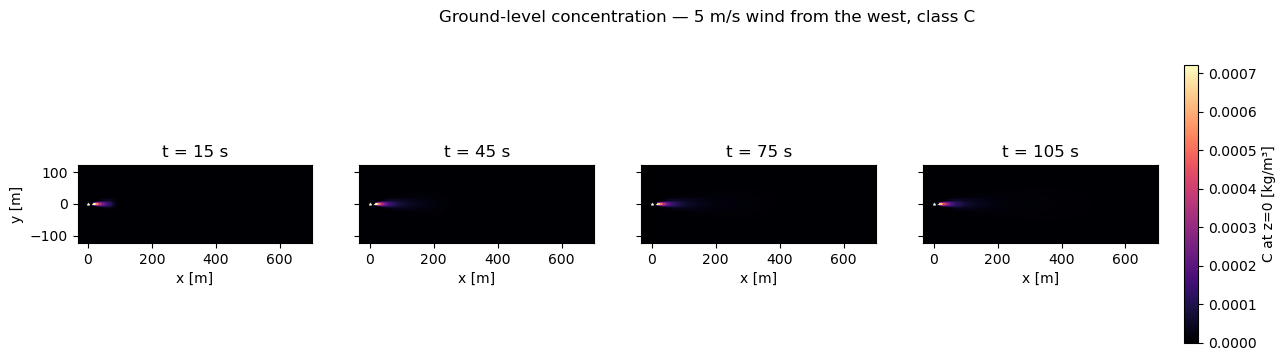

In [3]:
snapshots = [15.0, 45.0, 75.0, 105.0]
fig, axes = plt.subplots(1, len(snapshots), figsize=(4.2 * len(snapshots), 4.0),
                          sharey=True)
vmax = float(ds["concentration"].sel(z=0, method="nearest").max())
for ax, t_k in zip(axes, snapshots):
    field = ds["concentration"].sel(time=t_k, method="nearest").sel(z=0, method="nearest")
    im = ax.pcolormesh(
        ds["x"], ds["y"], field.T,
        cmap="magma", vmin=0.0, vmax=vmax, shading="auto",
    )
    ax.scatter([0], [0], c="w", s=40, marker="*", edgecolors="k", label="source")
    ax.set_title(f"t = {t_k:.0f} s")
    ax.set_xlabel("x [m]")
    ax.set_aspect("equal")
axes[0].set_ylabel("y [m]")
cbar = fig.colorbar(im, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label("C at z=0 [kg/m³]")
fig.suptitle("Ground-level concentration — 5 m/s wind from the west, class C")
plt.show()

Each snapshot shows a lumpy "trail" of puffs stretching downwind — near the source the individual puff peaks are still resolved (release interval 0.5 s, puff-width growing from ~0.5 m), but by a few hundred metres the puffs overlap into a smooth plume.

### Column integral

The column-integrated concentration `∫ C dz` [kg/m²] — what a remote-sensing instrument in the vertical would see — smooths over the z-structure.

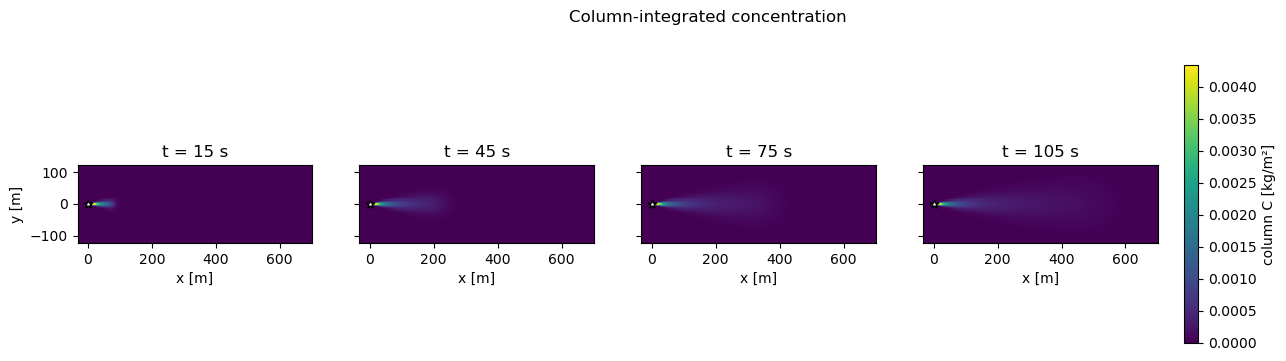

In [4]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(4.2 * len(snapshots), 4.0),
                          sharey=True)
vmax_col = float(ds["column_concentration"].max())
for ax, t_k in zip(axes, snapshots):
    field = ds["column_concentration"].sel(time=t_k, method="nearest")
    im = ax.pcolormesh(
        ds["x"], ds["y"], field.T,
        cmap="viridis", vmin=0.0, vmax=vmax_col, shading="auto",
    )
    ax.scatter([0], [0], c="w", s=40, marker="*", edgecolors="k")
    ax.set_title(f"t = {t_k:.0f} s")
    ax.set_xlabel("x [m]")
    ax.set_aspect("equal")
axes[0].set_ylabel("y [m]")
cbar = fig.colorbar(im, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label("column C [kg/m²]")
fig.suptitle("Column-integrated concentration")
plt.show()

## 2. Vertical cross-section along the plume centreline

Slice at y = 0 showing how mass spreads vertically as it travels downwind. Ground reflection keeps the concentration highest near z = 0 for a low-elevated source.

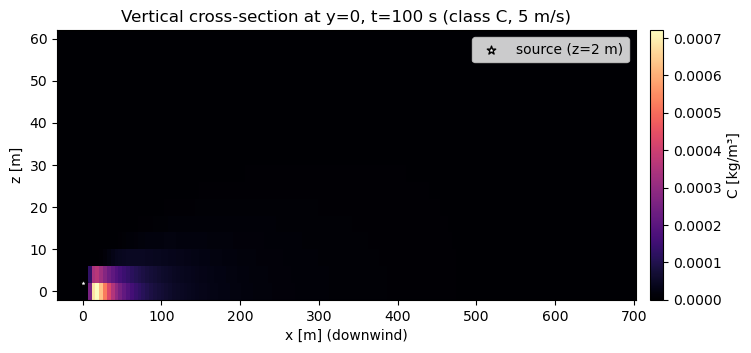

In [5]:
t_eval = 100.0
slice_yz = ds["concentration"].sel(time=t_eval, method="nearest").sel(y=0, method="nearest")

fig, ax = plt.subplots(figsize=(9, 3.5))
pcm = ax.pcolormesh(
    ds["x"], ds["z"], slice_yz.T,
    cmap="magma", shading="auto",
)
ax.scatter([0], [2], c="w", s=40, marker="*", edgecolors="k", label="source (z=2 m)")
ax.set_xlabel("x [m] (downwind)")
ax.set_ylabel("z [m]")
ax.set_title(f"Vertical cross-section at y=0, t={t_eval:.0f} s (class C, 5 m/s)")
cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("C [kg/m³]")
ax.legend(loc="upper right")
plt.show()

## 3. Downwind transect vs. time

Following the concentration at a fixed downwind receptor over the simulation window gives the arrival-and-decay curve every in-situ sensor sees. The puff field builds up as successive puffs pass the receptor, and approaches a steady value once the source has been running long enough for puffs born "outside" the domain of interest.

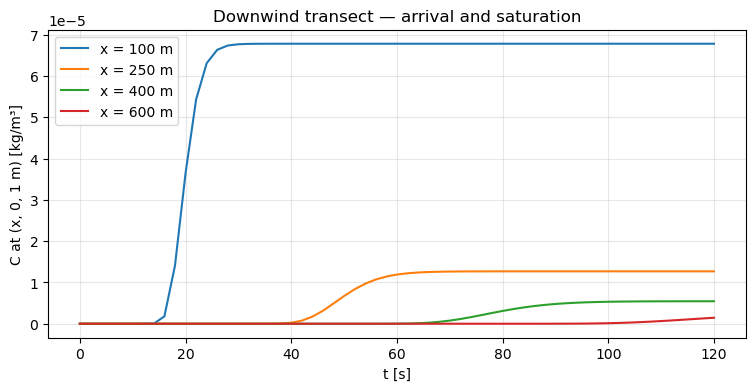

In [6]:
receptors_x = [100.0, 250.0, 400.0, 600.0]
fig, ax = plt.subplots(figsize=(9, 4))
for x_r in receptors_x:
    curve = ds["concentration"].sel(x=x_r, method="nearest").sel(
        y=0, method="nearest").sel(z=1, method="nearest")
    ax.plot(ds["time"], curve, label=f"x = {x_r:.0f} m")
ax.set_xlabel("t [s]")
ax.set_ylabel("C at (x, 0, 1 m) [kg/m³]")
ax.set_title("Downwind transect — arrival and saturation")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 4. Stability-class sweep

For the same wind and emission rate, stability class controls how aggressively puffs spread. Class A (very unstable) has the widest puffs and lowest centreline concentration; class F (very stable) keeps the plume narrow and hot.

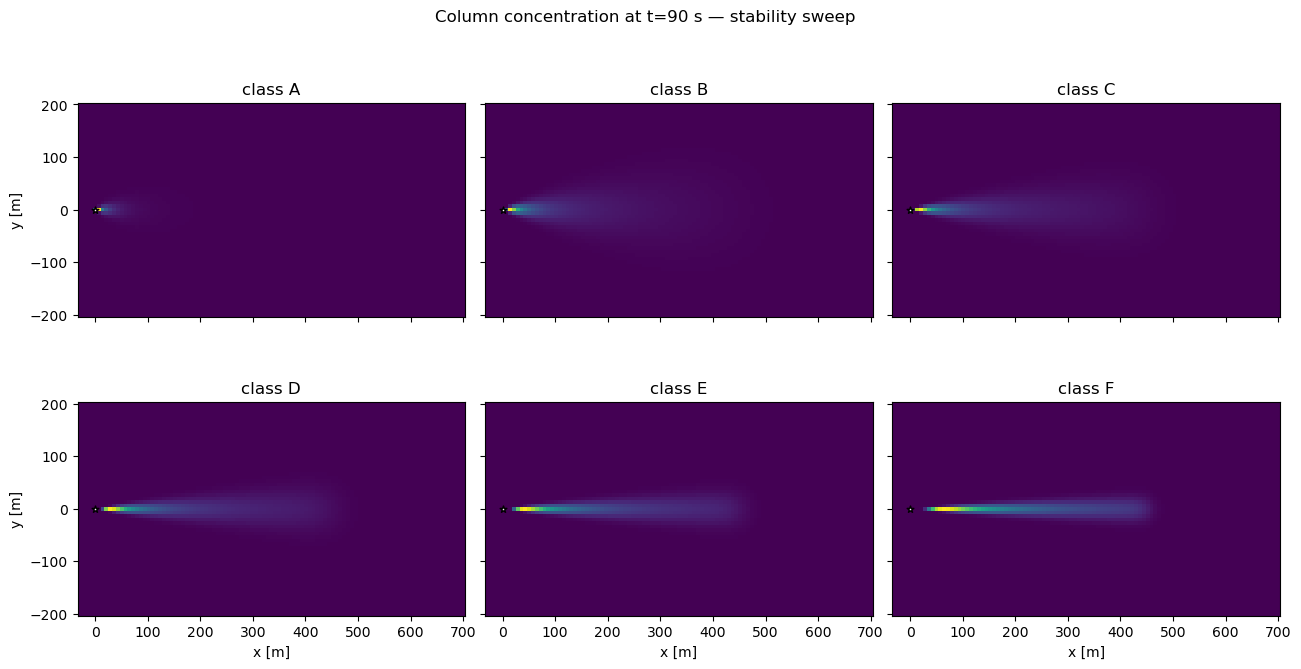

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
snap_t = 90.0
for ax, cls in zip(axes.ravel(), "ABCDEF"):
    ds_cls = simulate_puff(
        emission_rate=0.1,
        source_location=(0.0, 0.0, 2.0),
        wind_speed=wind_speed,
        wind_direction=wind_direction,
        stability_class=cls,
        domain_x=(-30.0, 700.0, 101),
        domain_y=(-200.0, 200.0, 61),
        domain_z=(0.0, 40.0, 9),
        time_array=time_array,
        release_frequency=2.0,
    )
    field = ds_cls["column_concentration"].sel(time=snap_t, method="nearest")
    im = ax.pcolormesh(
        ds_cls["x"], ds_cls["y"], field.T,
        cmap="viridis", shading="auto",
    )
    ax.set_title(f"class {cls}")
    ax.set_aspect("equal")
    ax.scatter([0], [0], c="w", s=25, marker="*", edgecolors="k")
for ax in axes[-1, :]:
    ax.set_xlabel("x [m]")
for ax in axes[:, 0]:
    ax.set_ylabel("y [m]")
fig.suptitle(f"Column concentration at t={snap_t:.0f} s — stability sweep")
plt.tight_layout()
plt.show()

## 5. Time-varying wind

Diffrax-driven cumulative integration lets us advect puffs under arbitrary wind histories. Here the wind direction sweeps 30° during the simulation — a "wind shift" event — and the plume bends accordingly. The steady plume model cannot represent this scenario at all.

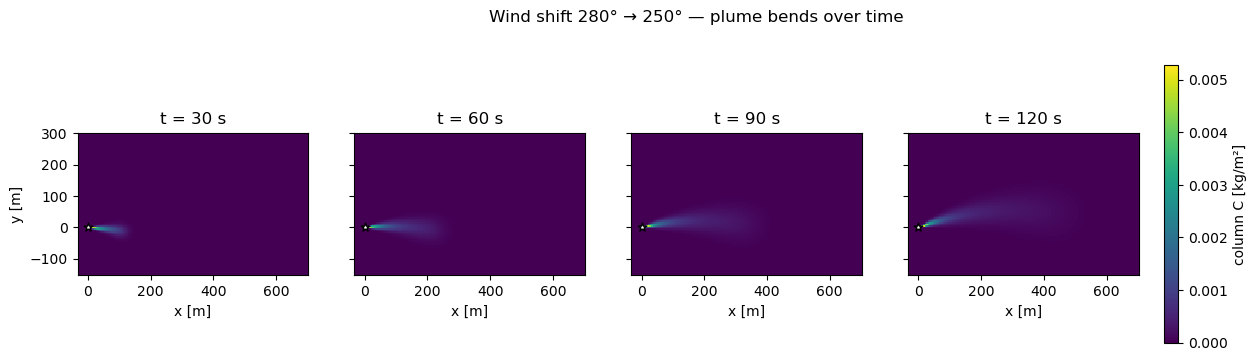

In [8]:
wind_speed_sweep = np.full(n_t, 4.0, dtype=np.float32)
# Linear sweep 280° → 250° (wind rotates counterclockwise from the "from-west"
# direction, pulling the plume's downwind axis upward in y).
wind_direction_sweep = np.linspace(280.0, 250.0, n_t).astype(np.float32)

ds_sweep = simulate_puff(
    emission_rate=0.1,
    source_location=(0.0, 0.0, 2.0),
    wind_speed=wind_speed_sweep,
    wind_direction=wind_direction_sweep,
    stability_class="C",
    domain_x=(-30.0, 700.0, 141),
    domain_y=(-150.0, 300.0, 91),
    domain_z=(0.0, 40.0, 9),
    time_array=time_array,
    release_frequency=2.0,
)

fig, axes = plt.subplots(1, 4, figsize=(16.5, 4.0), sharey=True)
sweep_snaps = [30.0, 60.0, 90.0, 120.0]
vmax = float(ds_sweep["column_concentration"].max())
for ax, t_k in zip(axes, sweep_snaps):
    field = ds_sweep["column_concentration"].sel(time=t_k, method="nearest")
    im = ax.pcolormesh(
        ds_sweep["x"], ds_sweep["y"], field.T,
        cmap="viridis", vmin=0.0, vmax=vmax, shading="auto",
    )
    ax.scatter([0], [0], c="w", s=40, marker="*", edgecolors="k")
    ax.set_title(f"t = {t_k:.0f} s")
    ax.set_xlabel("x [m]")
    ax.set_aspect("equal")
axes[0].set_ylabel("y [m]")
cbar = fig.colorbar(im, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label("column C [kg/m²]")
fig.suptitle("Wind shift 280° → 250° — plume bends over time")
plt.show()

Older puffs were advected under the earlier (more westerly) wind and sit at lower y; newer puffs track the rotated direction. The bent trail is a signature diagnostic of non-stationarity and motivates the state-estimation workflow in [03_puff_state_estimation.ipynb](03_puff_state_estimation.ipynb).

## What next?

- [02_emission_rate_parameter_estimation.ipynb](02_emission_rate_parameter_estimation.ipynb) — recover a constant Q from a time-series of downwind sensor readings via NUTS.
- [03_puff_state_estimation.ipynb](03_puff_state_estimation.ipynb) — infer a time-varying emission series Q_i with a random-walk prior.